# Optimize smoothing for your experiment

This notebook allows you to optimize the smoothing method / window applied to your data. It will iterate through a combination of smoothing windows and methods and visualize raw vs smoothed data and growth rate curves

First, set the PATH to your dataset. If you do not want to optimize on the entire dataset, modify the `exp = FluidExperiment(PATH)` to only load selected positions or color channels

in a first step, It will smooth the `VALUE_COLUMN` with each method in `METHODS` and smoothing windows specified in `SMOOTHING_WINDOWS`. To deactivate a method form the test, just comment it out. to add an additional method, import it and add the method schema to the list, following the examples

The routine will also time each method (in seconds), so you can estimate how long it will take for your entire dataset

in a 2nd step, it will visualize raw vs smoothed data for random examples for each combination

additionally, it will then calculate the growth rate base on smoothed data, and report the final rate curves to the user

In [ ]:
from fluid_experiment.fluid_experiment import FluidExperiment
from mutate.smooth import smooth_svagol, smooth_linear, smooth_loess_optimized, smooth_lowess_fast
import pandas as pd
import numpy as np

PATH = "../../data/midap-tools_example"
VALUE_COLUMN = "major_axis_length"
SMOOTHING_WINDOWS = [5, 7, 9] 
METHODS =  [
    {"name": "LINEAR",
     "desciption": "simple convolution (linear)",
     "postfix": "_linear",
     "function": smooth_linear},
    {"name": "SVAGOL",
     "desciption": "2nd order poly",
     "postfix": "_svagol",
     "function": smooth_svagol},
    {"name": "LOESS",
     "desciption": "vectorized loess with 2nd order",
     "postfix": "_loess",
     "function": smooth_loess_optimized},
    {"name": "LOWESS",
     "desciption": "vectorized lowess with 1st order",
     "postfix": "_lowess",
     "function": smooth_lowess_fast},
    
]
NOISE = 0.2  #uniform noise addition? set to 0 if not otherwise will multiply each measurement with a random value between 1 - NOISE and 1 + NOISE to simulate stronger noise

exp = FluidExperiment(PATH)
exp.load_metadata_template()
print(exp)

    


#add random noise to the data and then log transform
def add_noise_log(x: pd.Series, seed: int | None = None) -> pd.Series:
    rng = np.random.default_rng(seed)
    noise = rng.uniform(1 - NOISE, 1 + NOISE, size=len(x))
    return np.log(x * noise)

#some preprocessing
exp.filter_data("frame", max_value=80)   #we cut of data > frame 80
exp.filter_data("trackID", min_occurences=5)  #only retain cells with at least 5 datapoints
exp.calculate_transform_data(VALUE_COLUMN,custom_function=add_noise_log)
log_col_name = f"{VALUE_COLUMN}_log"


Loading sample at position pos1 for color channel YFP
Loading sample at position pos1 for color channel CFP
Loading sample at position pos2 for color channel YFP
Loading sample at position pos2 for color channel CFP
Loading sample at position pos3 for color channel YFP
Loading sample at position pos3 for color channel CFP
Loading sample at position pos4 for color channel YFP
Loading sample at position pos4 for color channel CFP
Loading sample at position pos5 for color channel YFP
Loading sample at position pos5 for color channel CFP
Loading sample at position pos6 for color channel YFP
Loading sample at position pos6 for color channel CFP
Successfully loaded data with consistent number of frames: 143
FluidExperiment with name: experiment
Path: ../../data/midap-tools_example
6 positions: pos1, pos2, pos3, pos4, pos5, pos6
2 color channels: YFP, CFP
length of experiment is consistent: 143
experiment has consistent headers: Unnamed: 0, globalID, frame, labelID, trackID, lineageID, trackI

# Smoothing with all methods and all integration windows

The loop below will iterate through all combinations of methods + smoothing window and apply it to the data

In [2]:
import time

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        name = m["name"]
        print(f"\nprocessing {name} at smoothing window {w}")
        t = time.time()
        exp.smooth_data(w, id_column="trackID", x_column= log_col_name, smoothed_postfix= m["postfix"] + f"_{w}", custom_method=m["function"])
        print(f"elapse time for {name} at smoothing window {w}: {round(time.time() - t,2)} seconds")


processing LINEAR at smoothing window 5
Smooth major_axis_length_log along frame over an integration window of 5 with CUSTOM method, adding new datacolumn of name major_axis_length_log_linear_5
elapse time for LINEAR at smoothing window 5: 3.51 seconds

processing SVAGOL at smoothing window 5
Smooth major_axis_length_log along frame over an integration window of 5 with CUSTOM method, adding new datacolumn of name major_axis_length_log_svagol_5
elapse time for SVAGOL at smoothing window 5: 4.91 seconds

processing LOESS at smoothing window 5
Smooth major_axis_length_log along frame over an integration window of 5 with CUSTOM method, adding new datacolumn of name major_axis_length_log_loess_5
elapse time for LOESS at smoothing window 5: 2.98 seconds

processing LOWESS at smoothing window 5
Smooth major_axis_length_log along frame over an integration window of 5 with CUSTOM method, adding new datacolumn of name major_axis_length_log_lowess_5
elapse time for LOWESS at smoothing window 5: 

# Create QC plots of all normalized data

The code below will create example plots for random trackIDs. the parameters `POS`, `N` and `COLOR_CHANNELS` allow you to define what and how much data should be plot


LINEAR at smoothing window 5: simple convolution (linear)


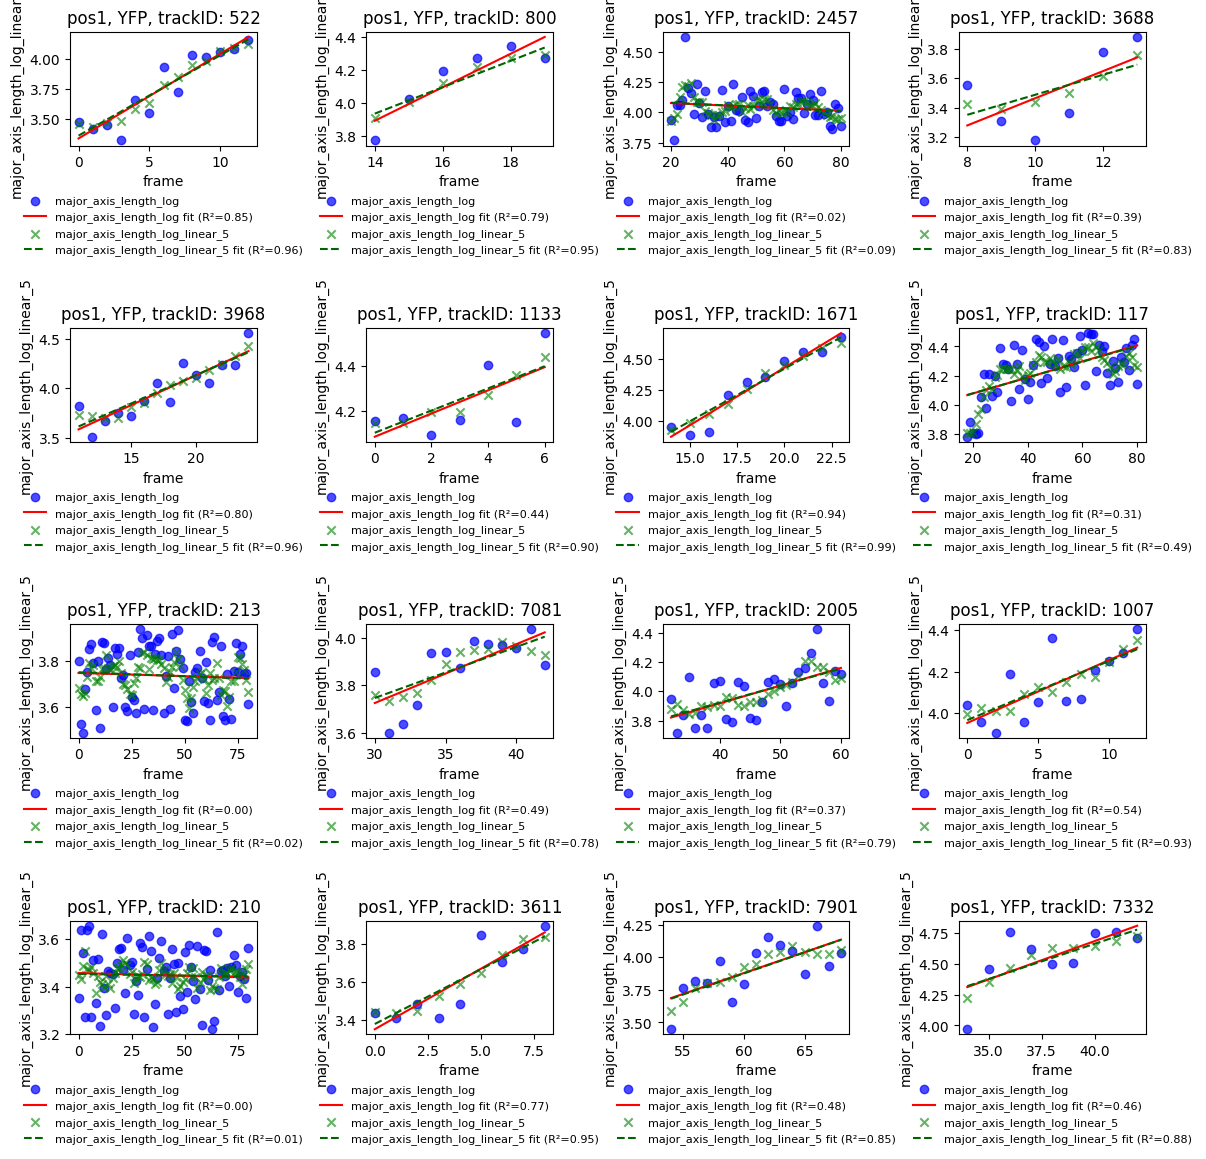


SVAGOL at smoothing window 5: 2nd order poly


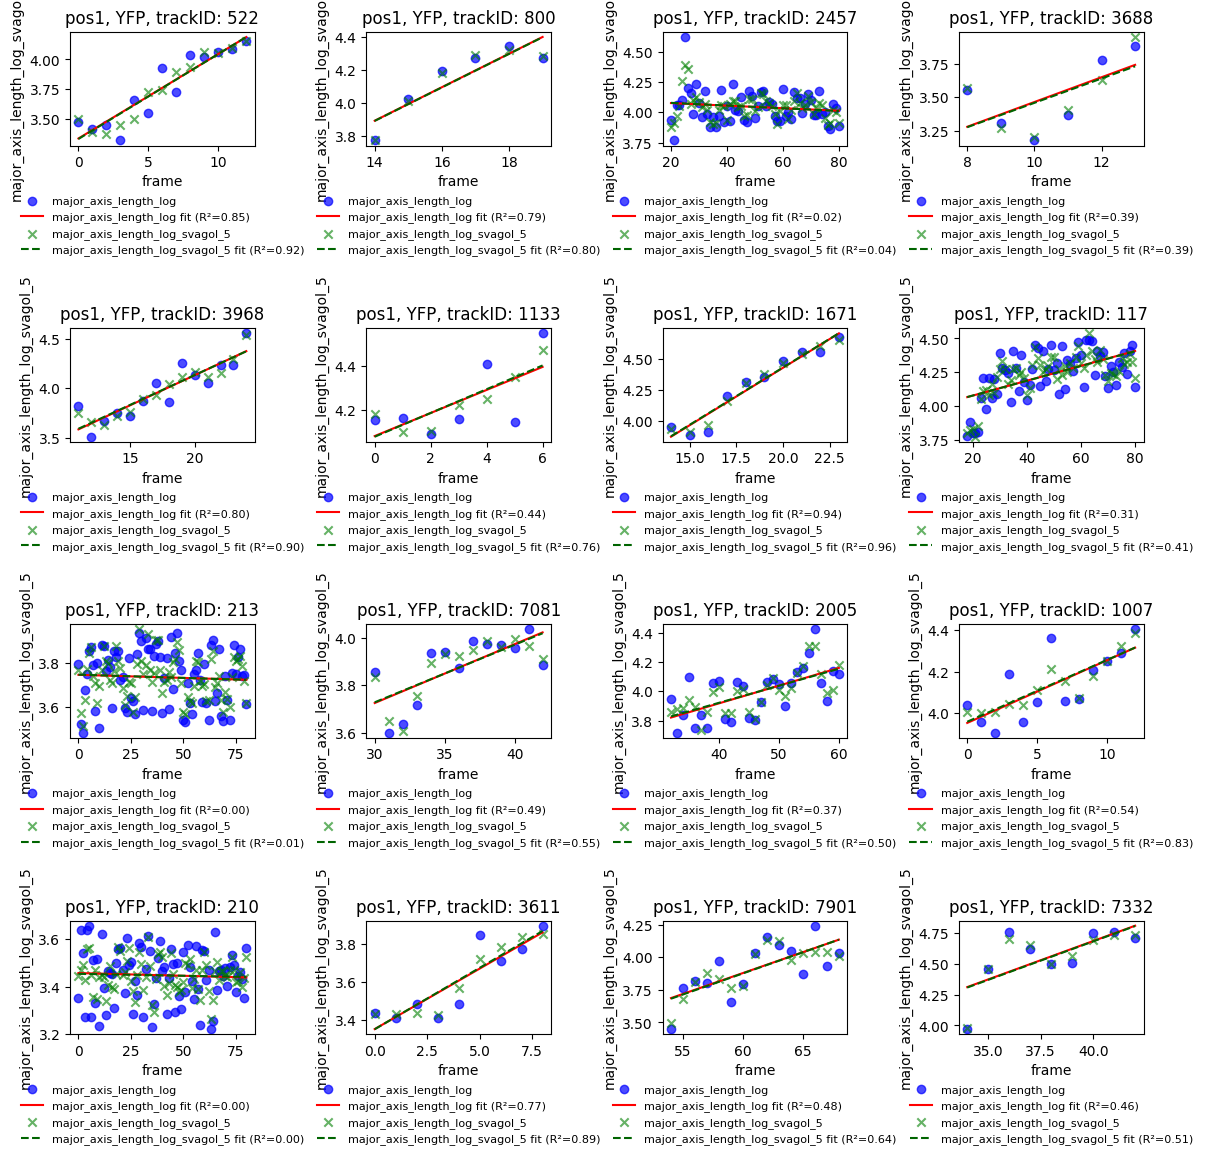


LOESS at smoothing window 5: vectorized loess with 2nd order


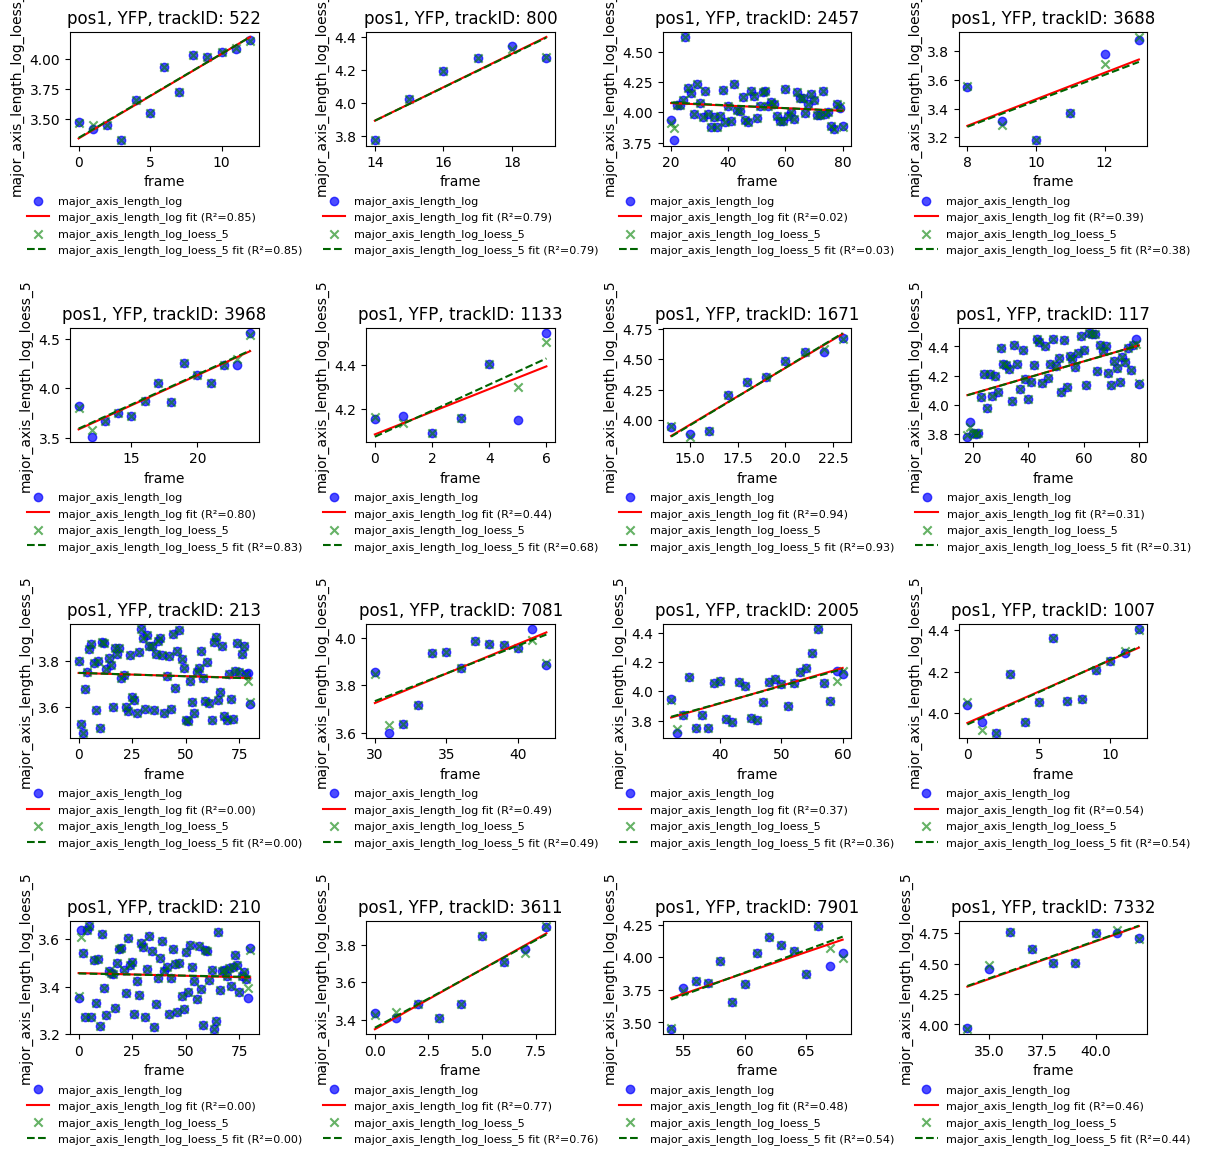


LOWESS at smoothing window 5: vectorized lowess with 1st order


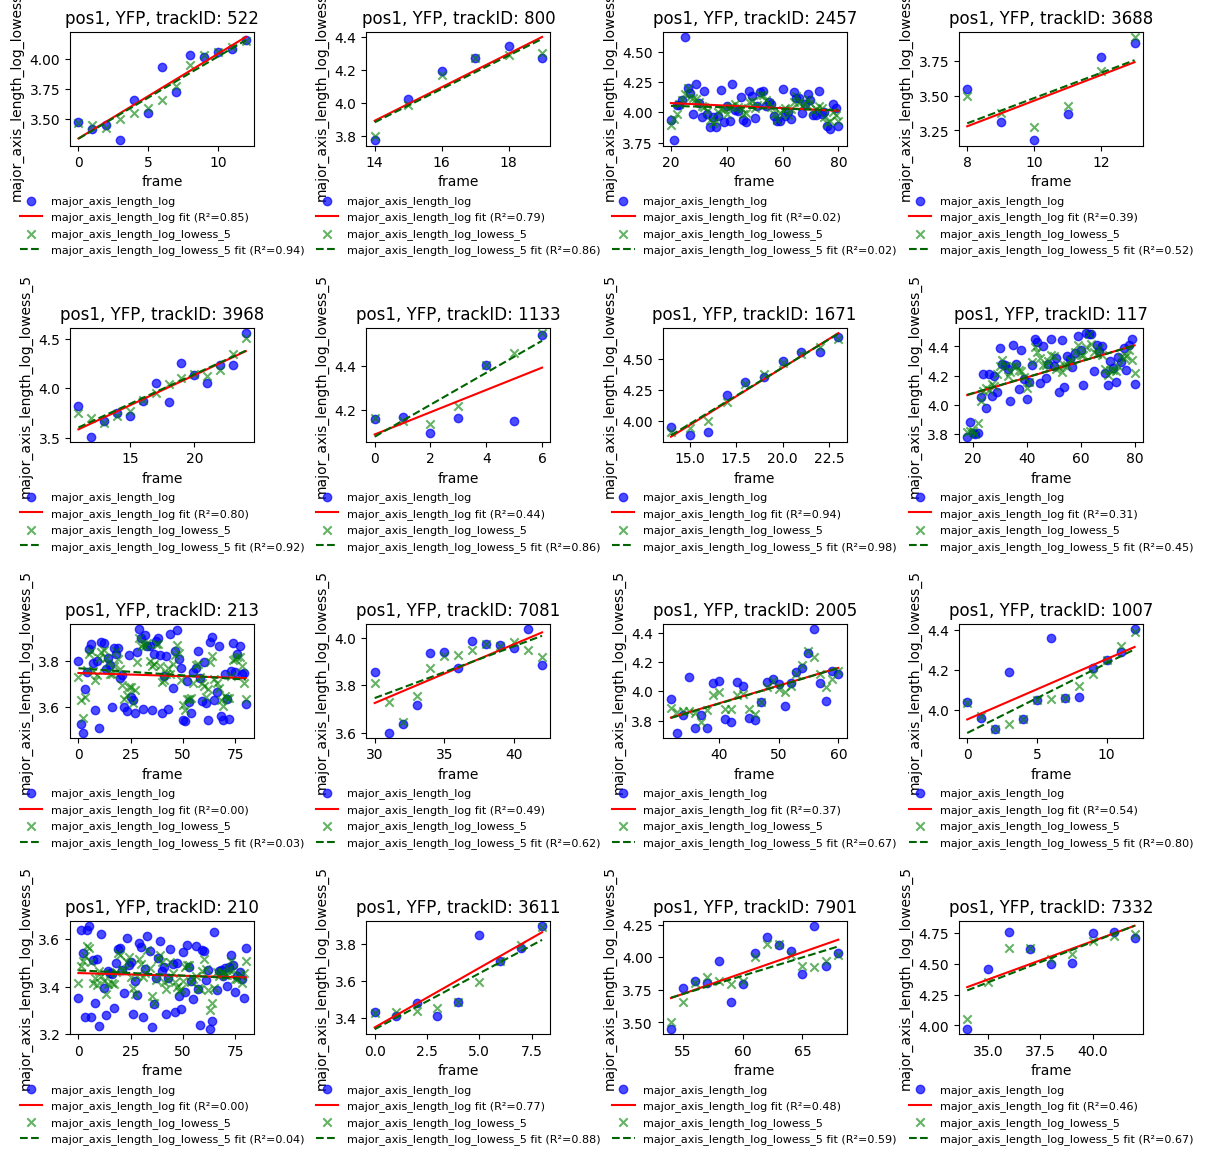


LINEAR at smoothing window 7: simple convolution (linear)


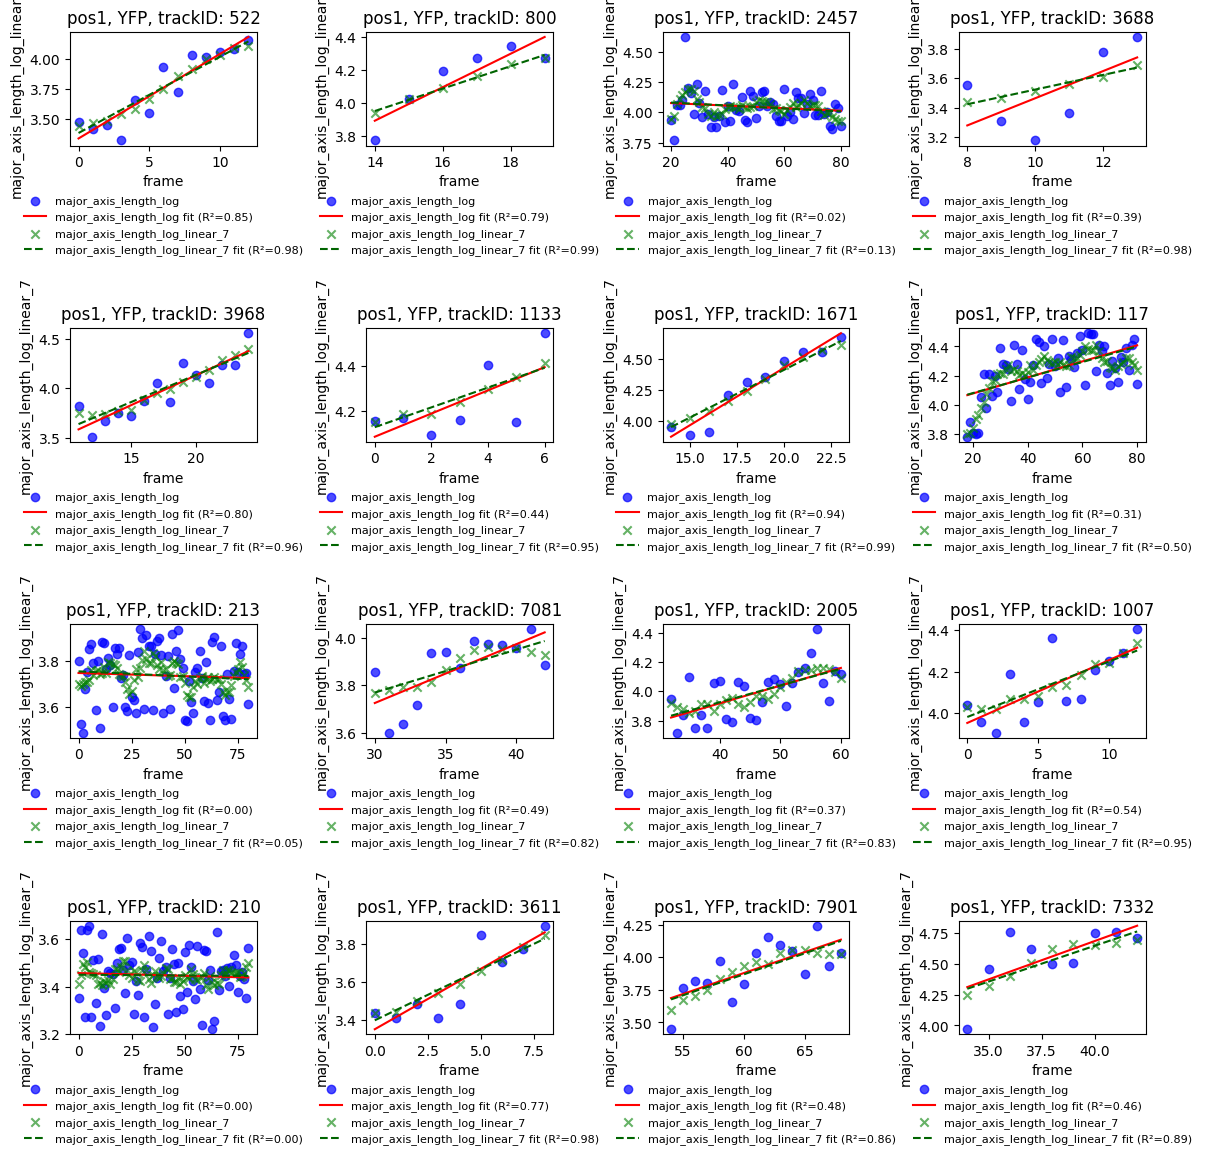


SVAGOL at smoothing window 7: 2nd order poly


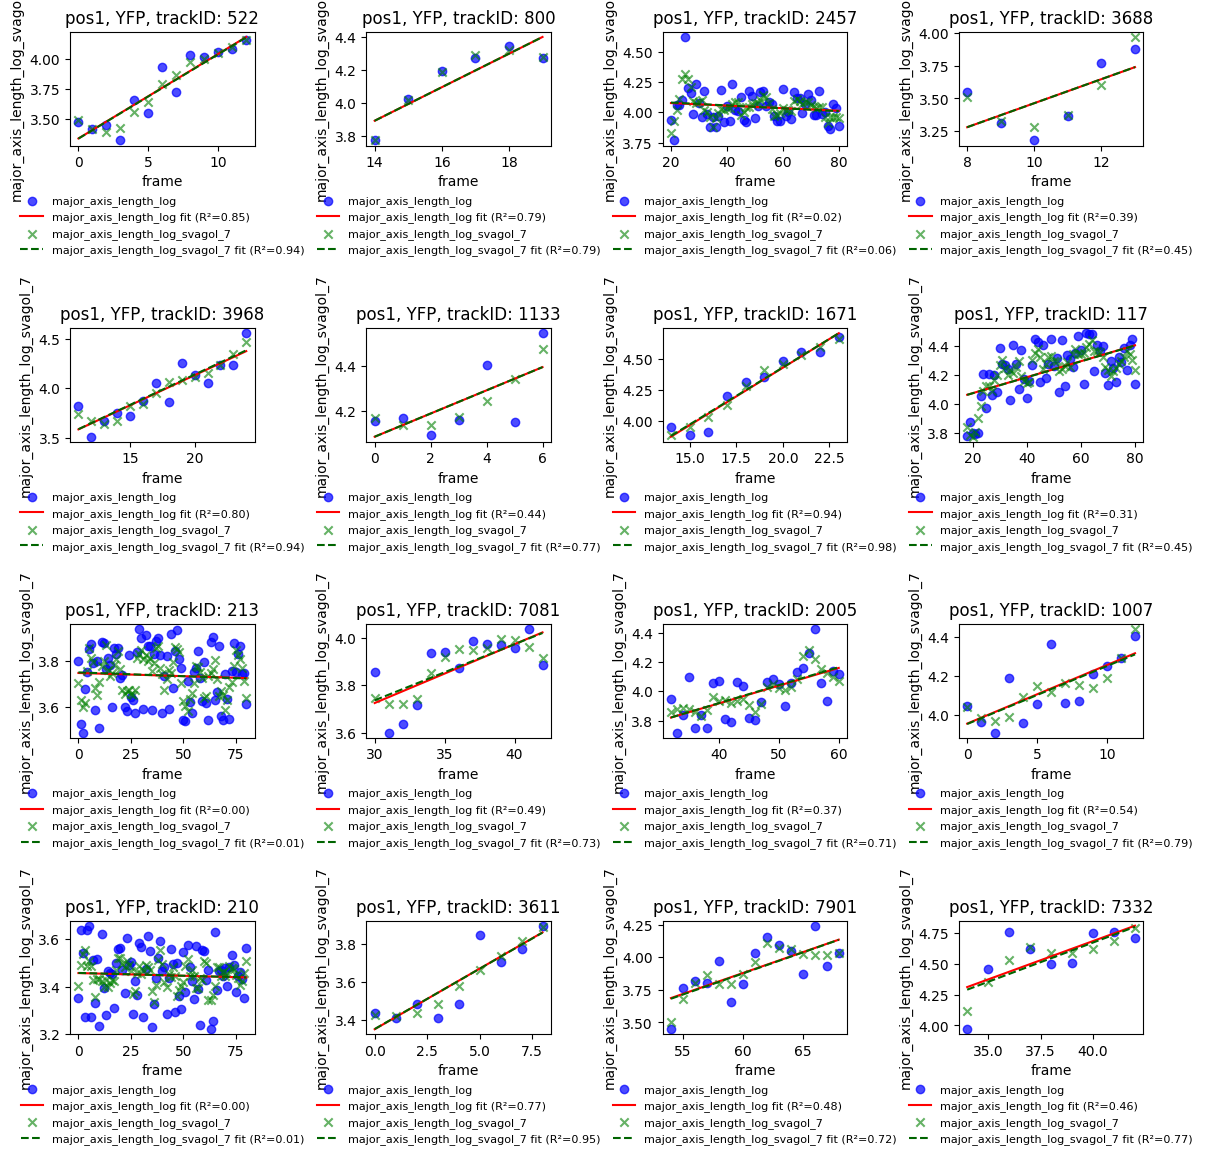


LOESS at smoothing window 7: vectorized loess with 2nd order


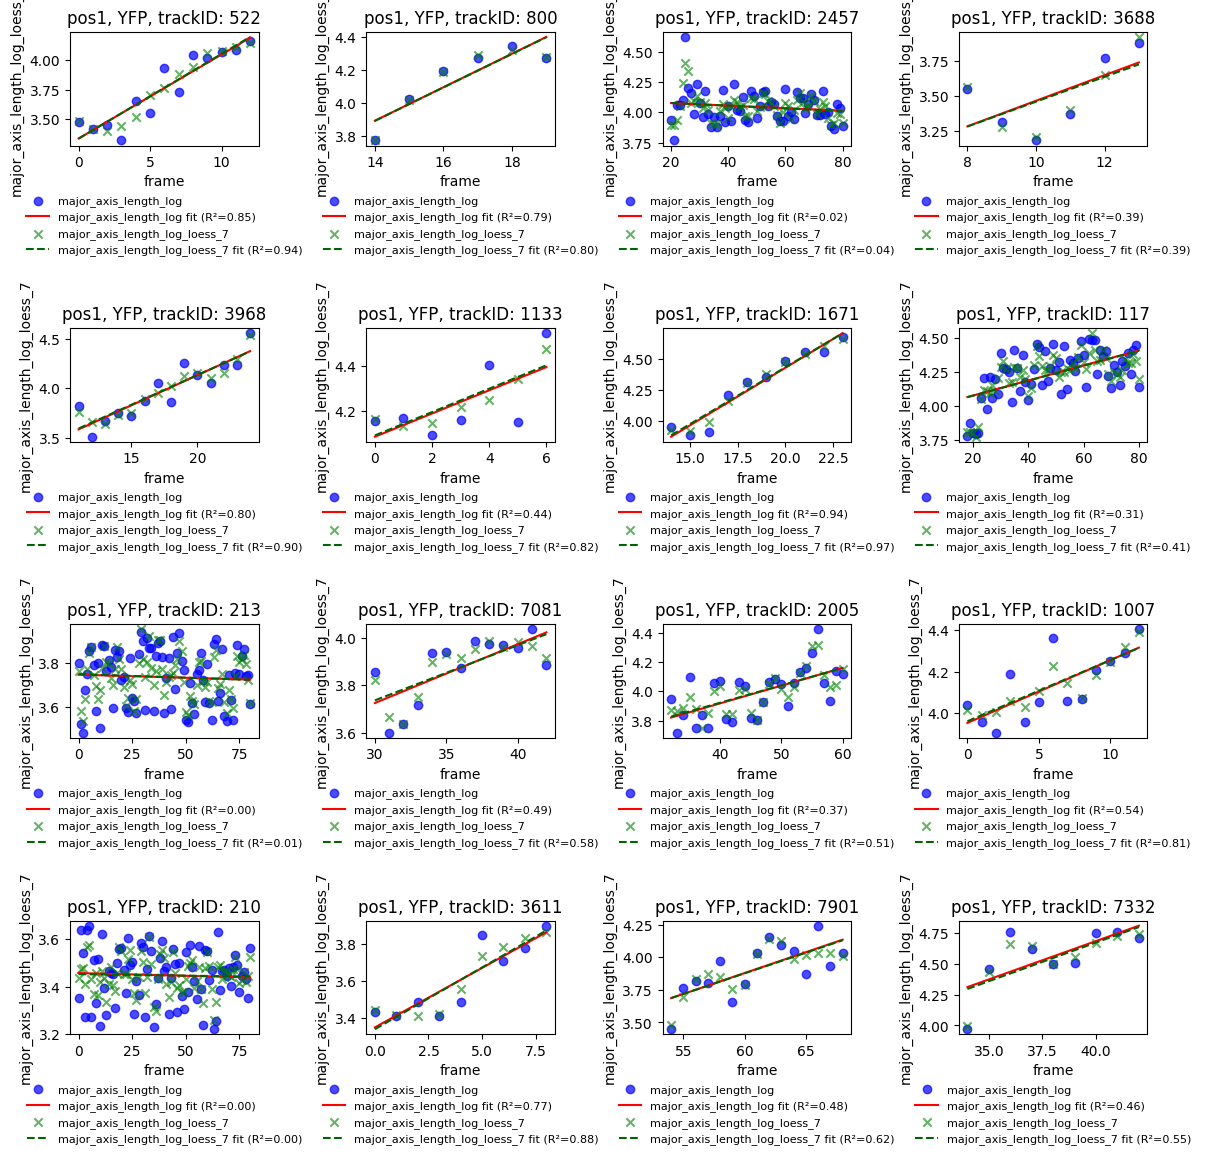


LOWESS at smoothing window 7: vectorized lowess with 1st order


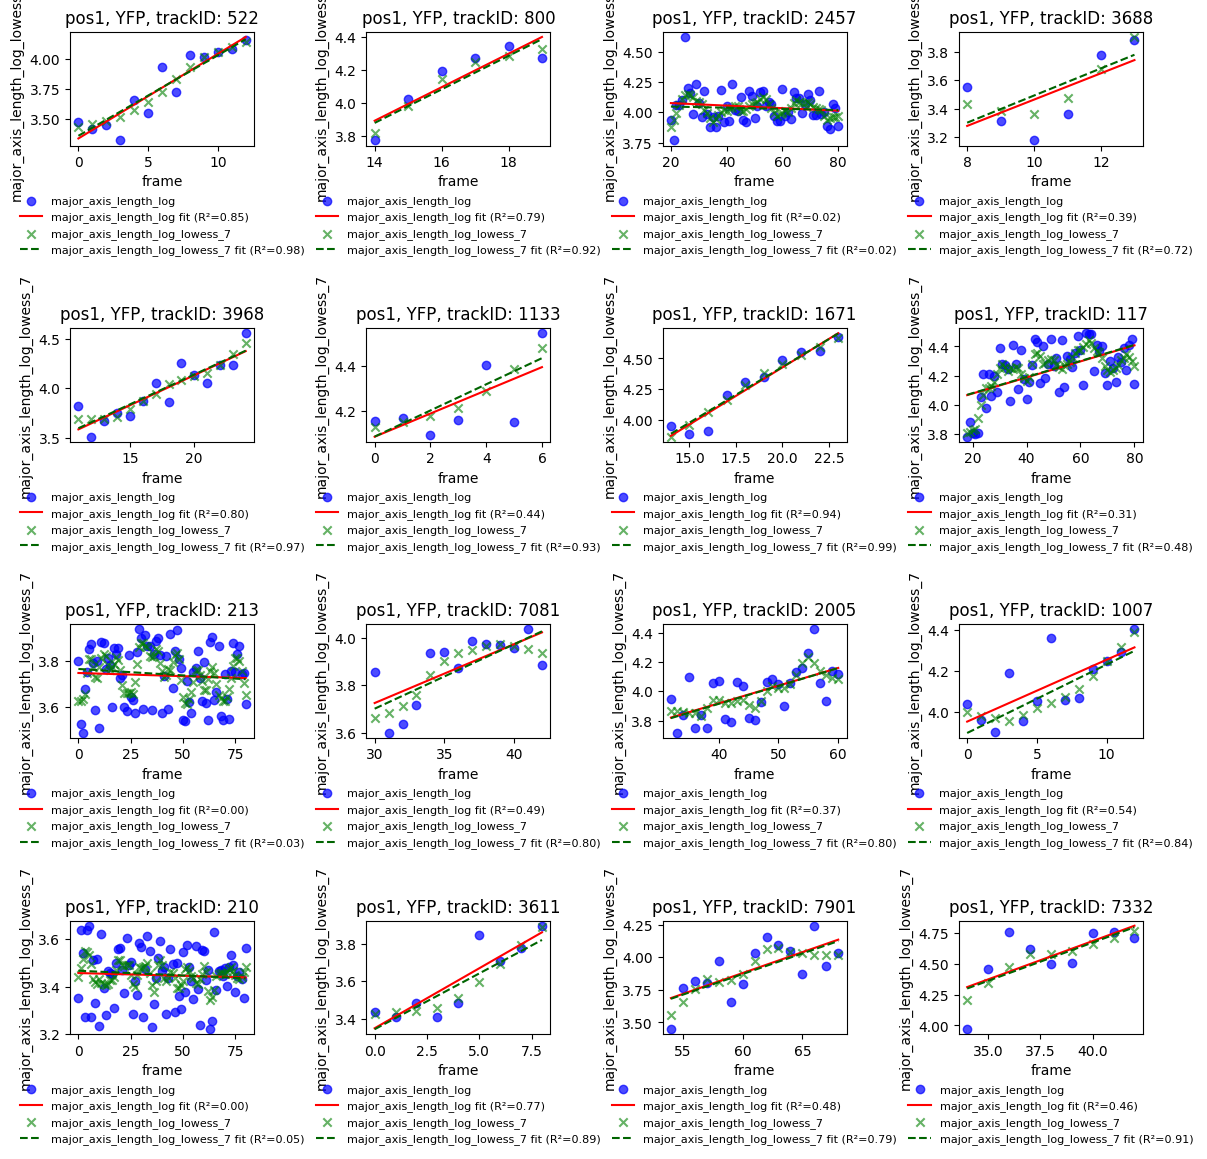


LINEAR at smoothing window 9: simple convolution (linear)


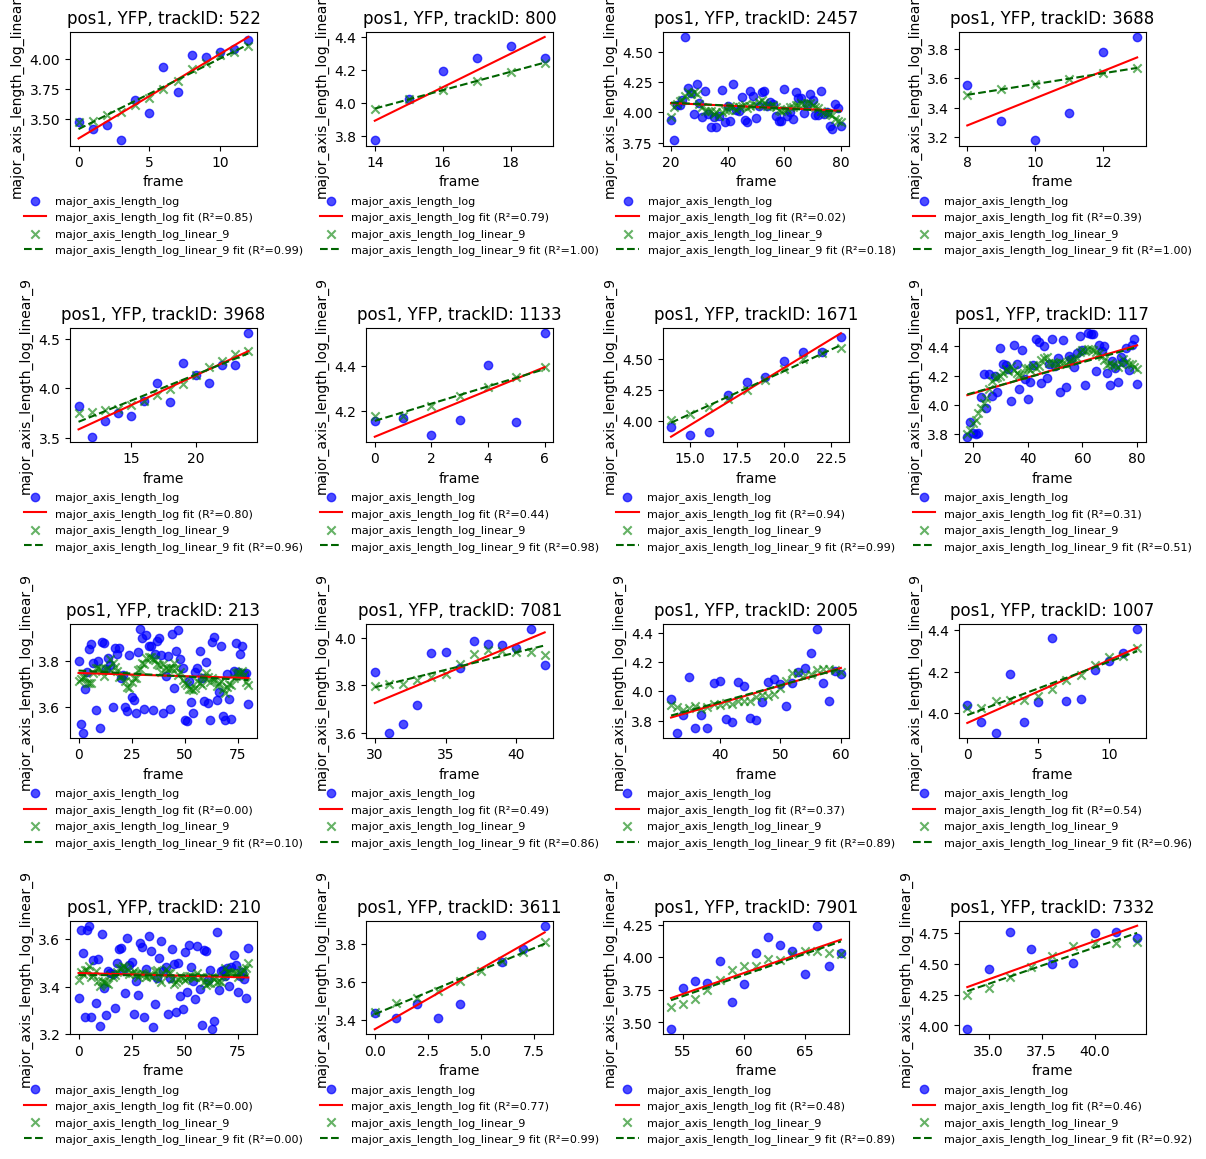


SVAGOL at smoothing window 9: 2nd order poly


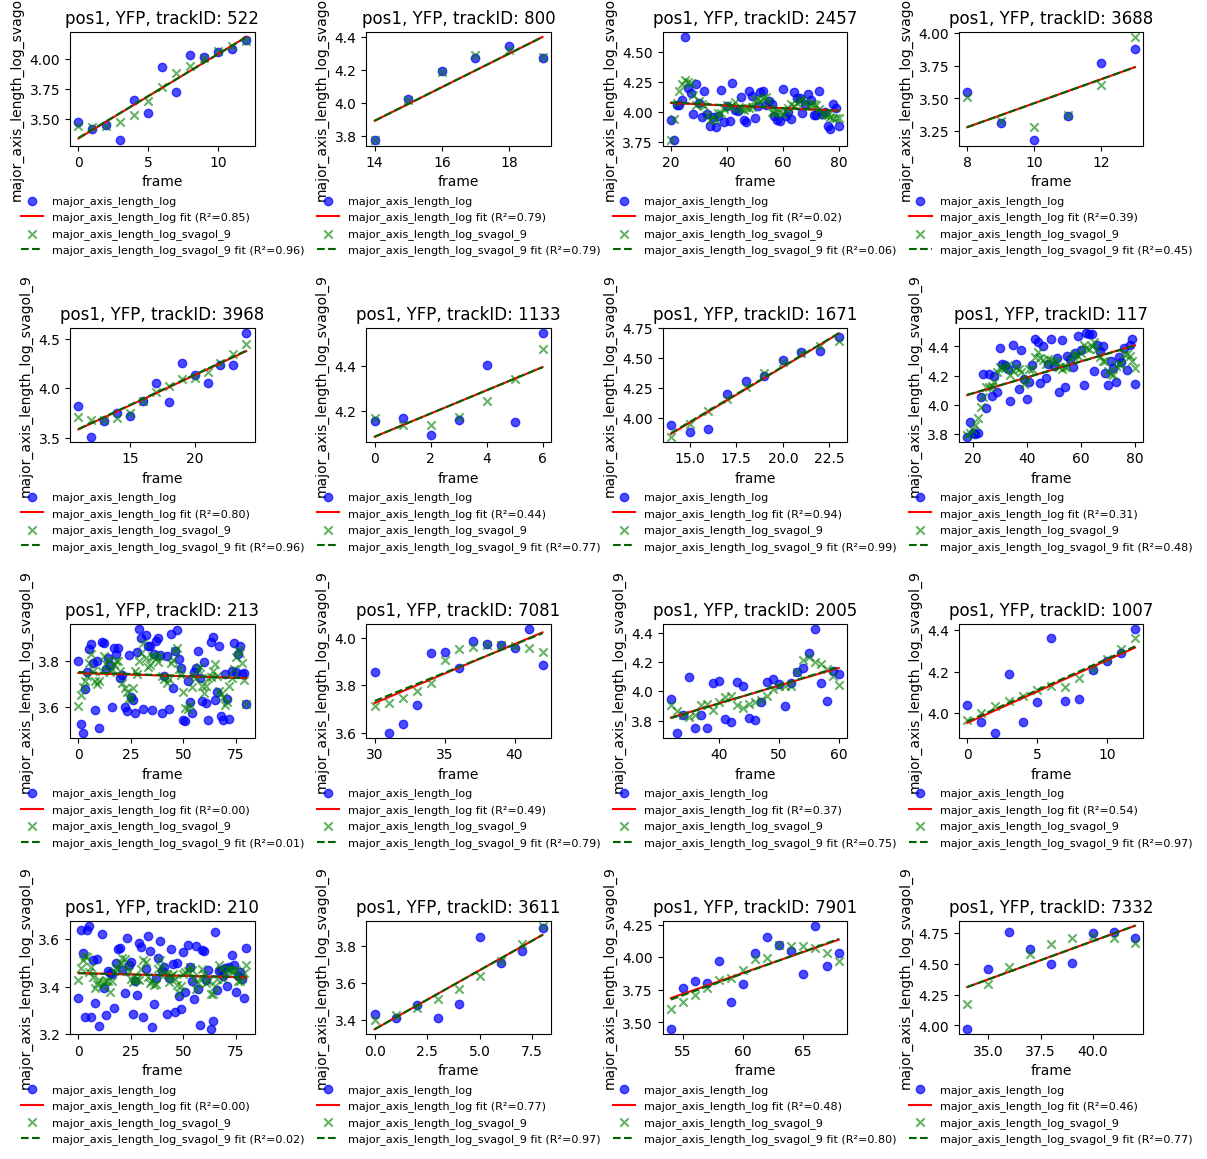


LOESS at smoothing window 9: vectorized loess with 2nd order


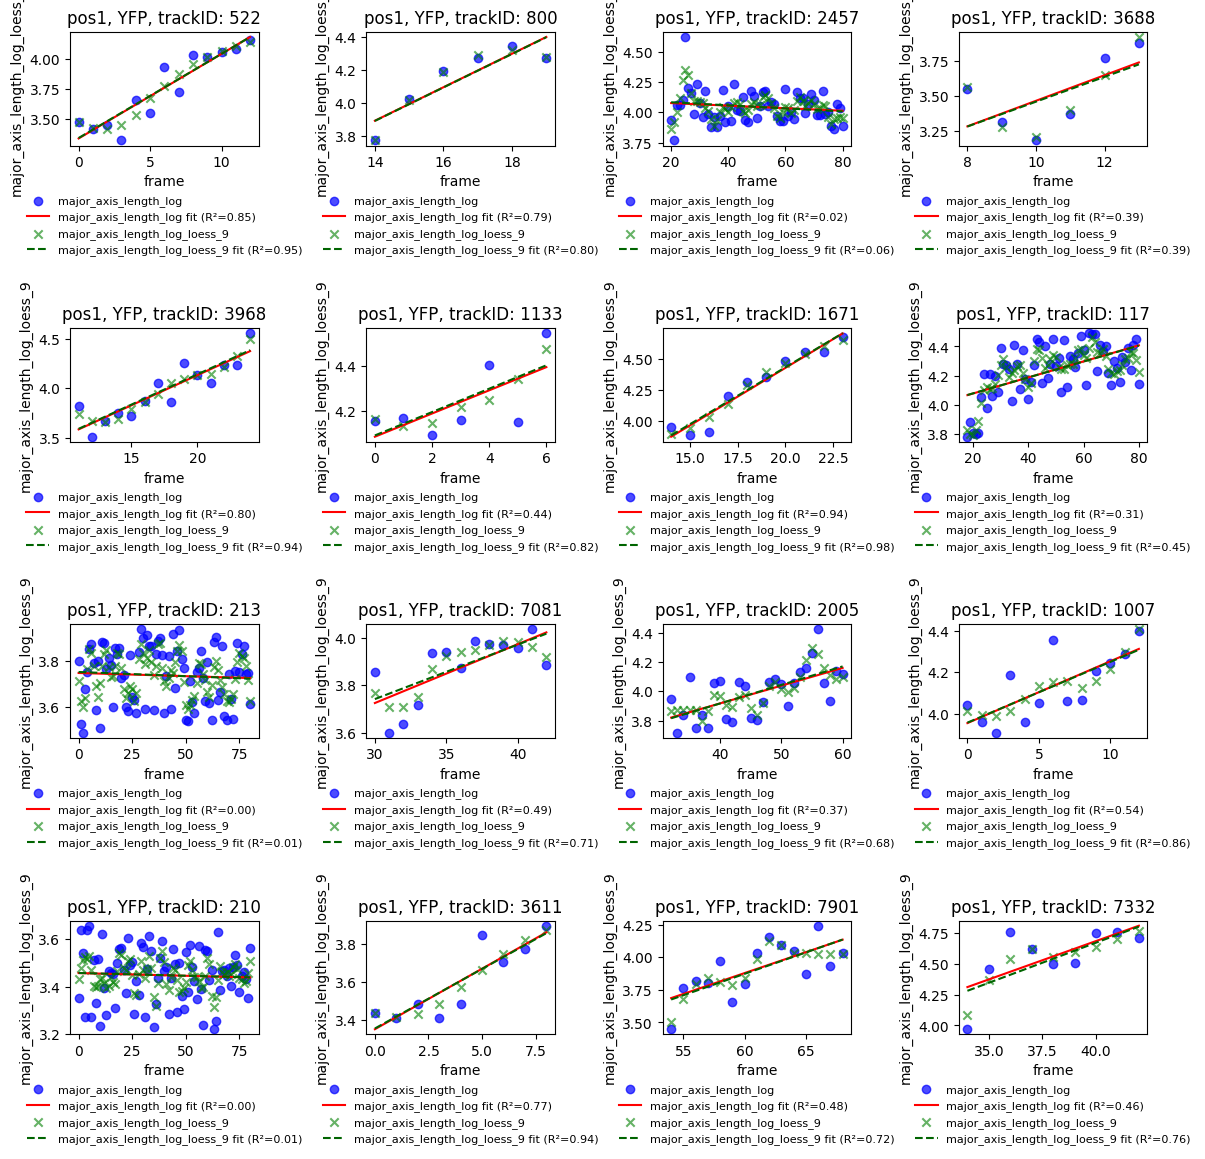


LOWESS at smoothing window 9: vectorized lowess with 1st order


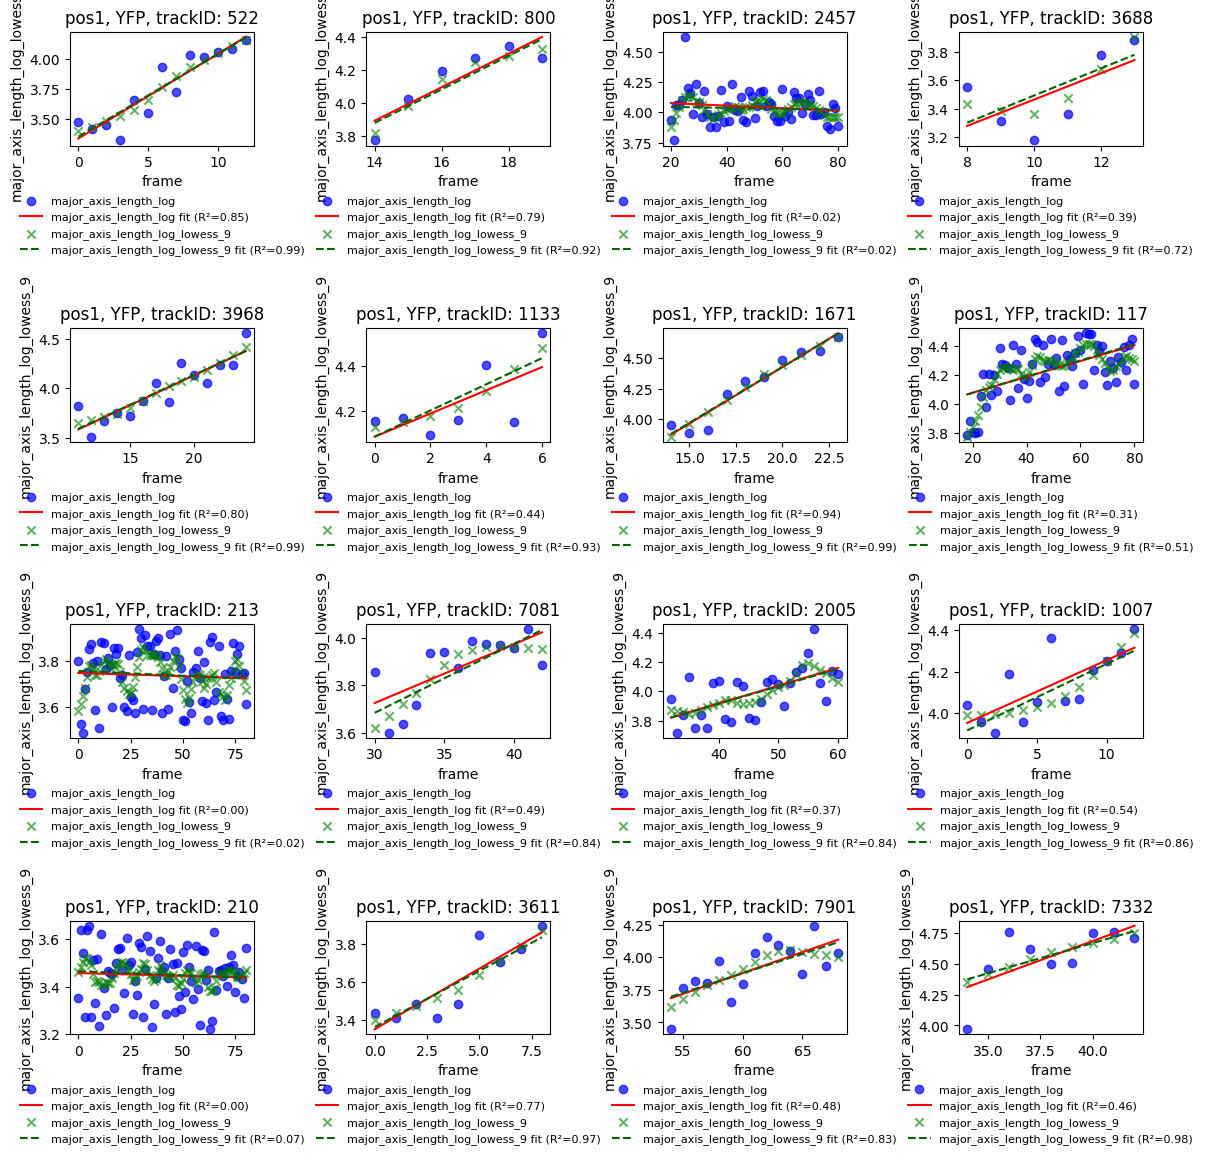

In [3]:
POS = ["pos1"]  #positions to plot data from
N = 16 # n examples to plot from each position / channel
COLOR_CHANNELS = ["YFP"] #channels to plot data from

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        name = m["name"]
        desc = m["desciption"]
        print(f"\n{name} at smoothing window {w}: {desc}")
        overlay_col_name = log_col_name + m["postfix"] + f"_{w}"
        exp.plot_qc(value_column=log_col_name,frame_column="frame", n_samples=N, overlay_column=overlay_col_name, free_overlay_axes= False, positions=POS, color_channels= COLOR_CHANNELS)


# Calculate growth rates with smoothed data

The loop below applies growth rate calculation (standard midap-tools method that calculates the average rate over the next `GROWTH_RATE_INTEGRATION` frames) to each smoothed data

In [ ]:
GROWTH_RATE_INTEGRATION = 5  #what integration period do we use when calculating the growth rate?

exp.calculate_growth_rate(5,"trackID",log_col_name, centric=True)  #growth rate from log raw data

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        method_column = log_col_name + m["postfix"] + f"_{w}"
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.calculate_growth_rate(GROWTH_RATE_INTEGRATION,"trackID", method_column,growth_rate_column=growth_rate_column)
    

Calculate growth_rate_linear_5 for trackID measured with major_axis_length_log_linear_5 over an integration window of 5
Calculate growth_rate_svagol_5 for trackID measured with major_axis_length_log_svagol_5 over an integration window of 5
Calculate growth_rate_loess_5 for trackID measured with major_axis_length_log_loess_5 over an integration window of 5
Calculate growth_rate_lowess_5 for trackID measured with major_axis_length_log_lowess_5 over an integration window of 5
Calculate growth_rate_linear_7 for trackID measured with major_axis_length_log_linear_7 over an integration window of 5
Calculate growth_rate_svagol_7 for trackID measured with major_axis_length_log_svagol_7 over an integration window of 5
Calculate growth_rate_loess_7 for trackID measured with major_axis_length_log_loess_7 over an integration window of 5
Calculate growth_rate_lowess_7 for trackID measured with major_axis_length_log_lowess_7 over an integration window of 5
Calculate growth_rate_linear_9 for trackID m

# create rate plots for a selected position / color channel

creates rate curve plots base on the growth rate calculated from all different smoothed data methods. `POS`  and `COLOR_CHANNELS` allow you to define what data to plot

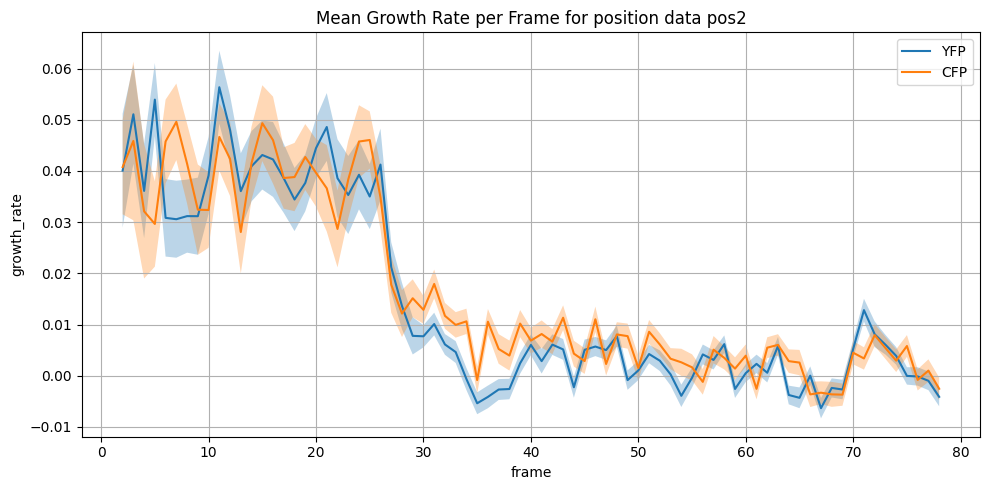

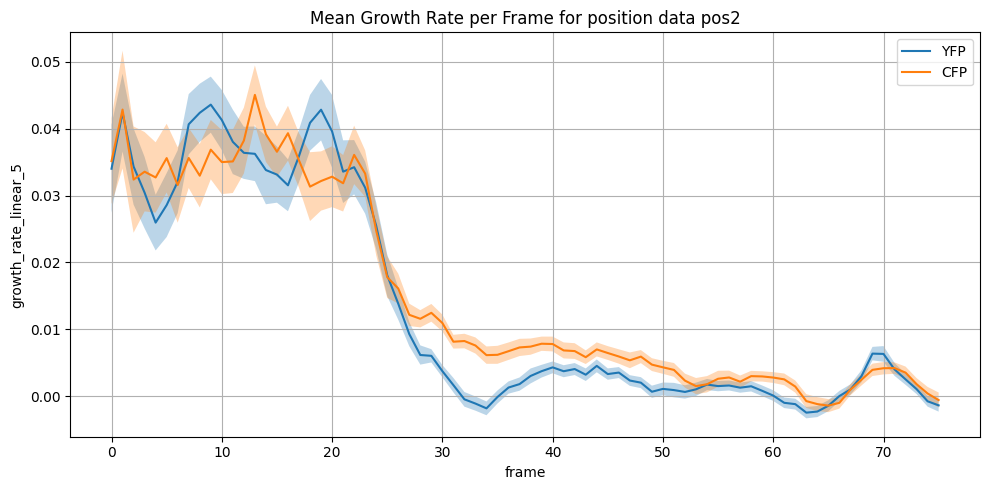

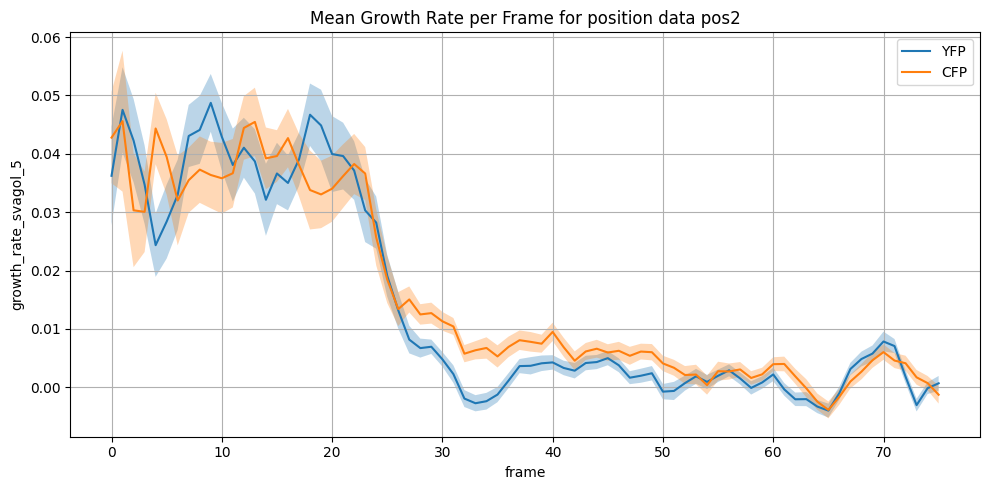

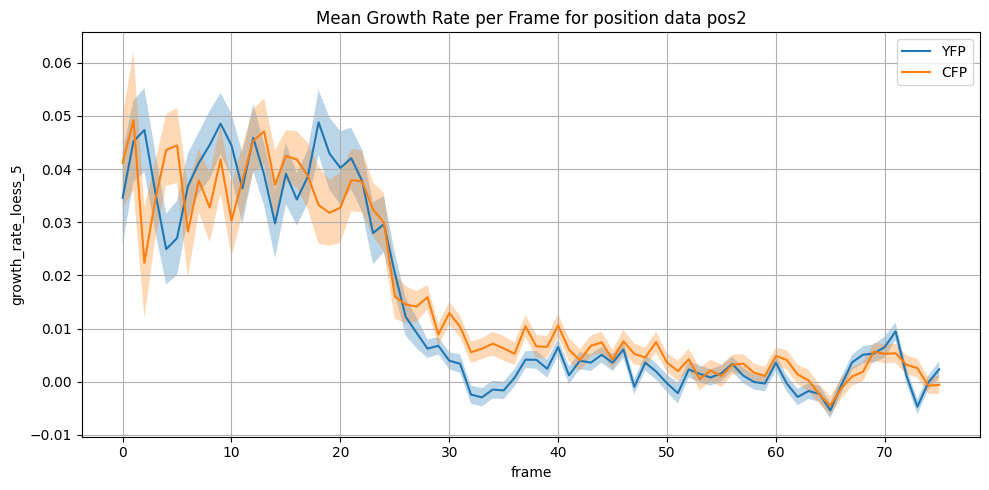

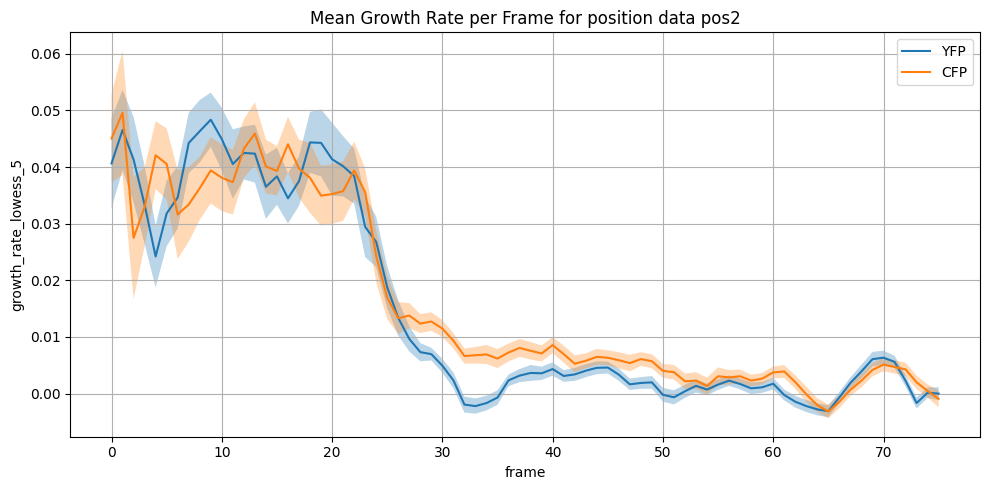

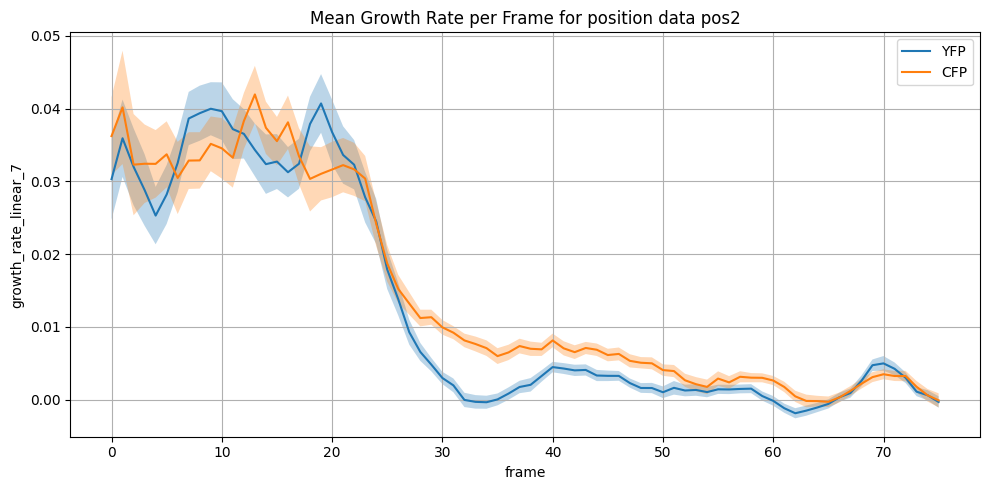

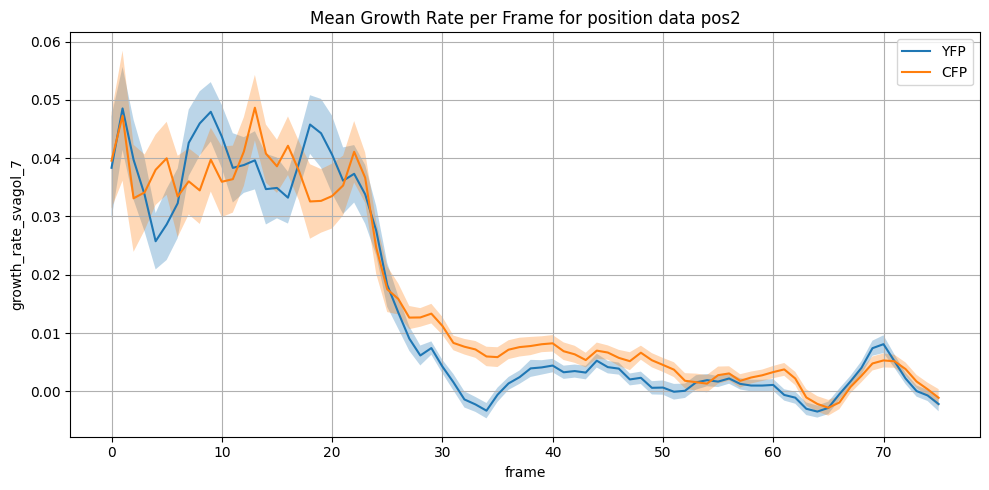

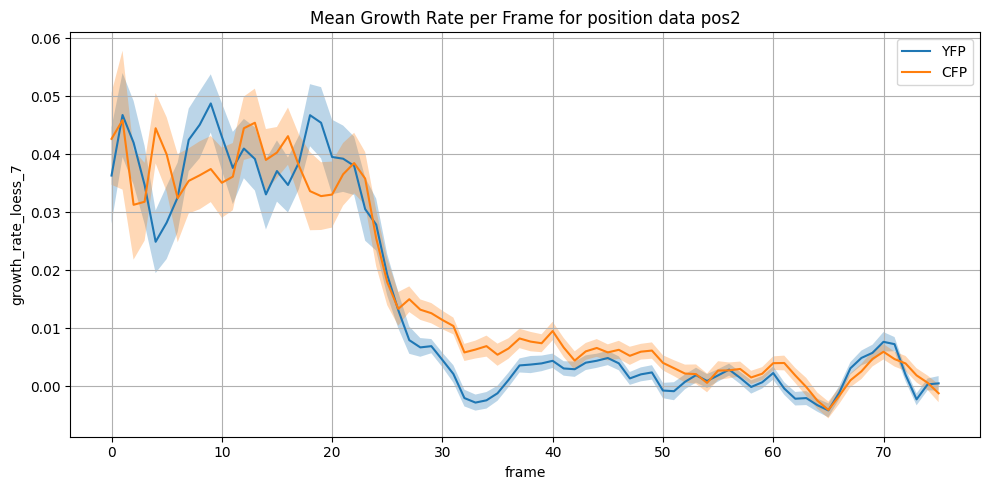

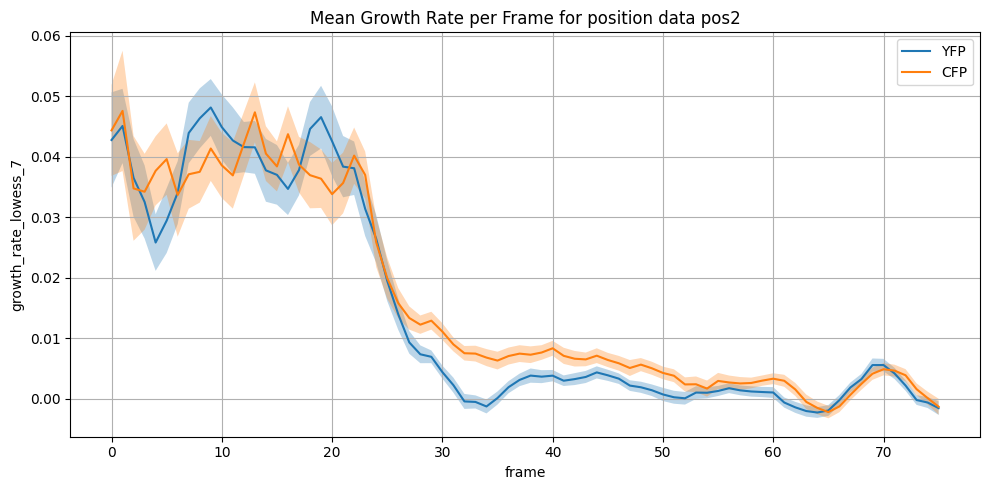

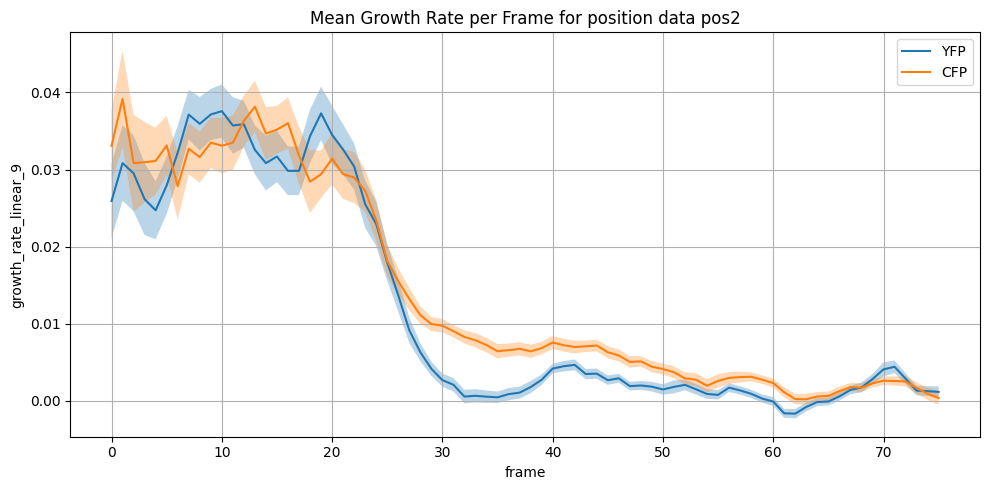

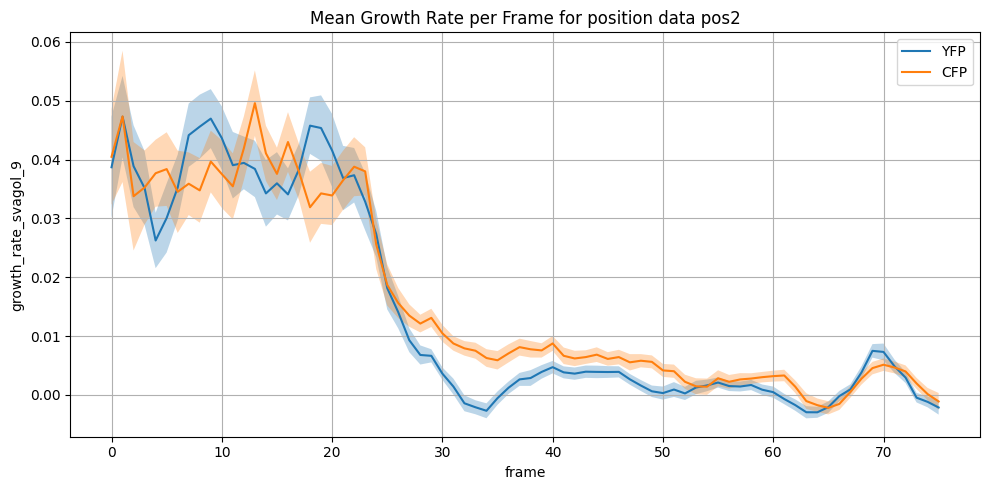

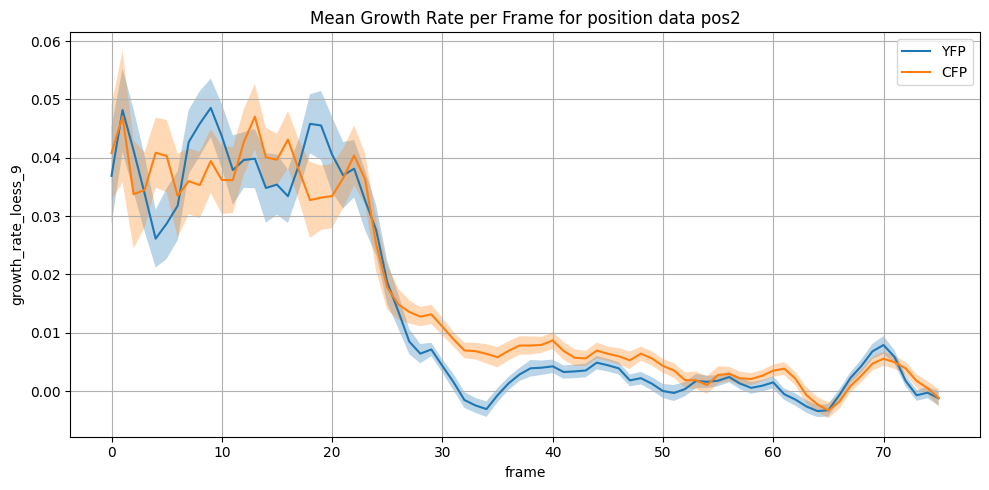

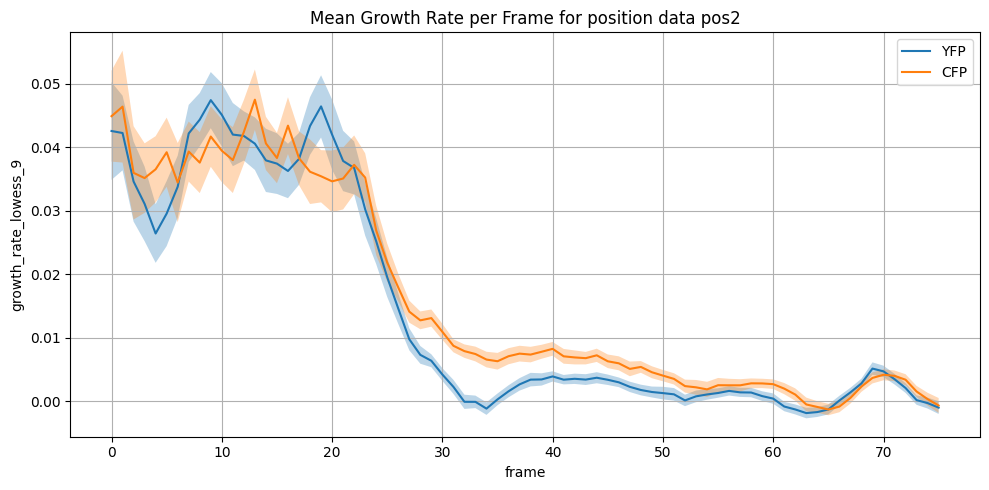

In [6]:
POS = ["pos2"]
COLOR_CHANNELS = ["YFP","CFP"]

exp.plot_rates(rate_column="growth_rate", positions= POS, color_channels = COLOR_CHANNELS)

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.plot_rates(rate_column=growth_rate_column, positions= POS, color_channels = COLOR_CHANNELS)

# create rate plots of groups based on smoothed data

creates rate curve plots base on the growth rate calculated from all different smoothed data methods and groups defined in your metadata `COLOR_CHANNELS` allows you to select channels to plot, with `METADATA_GROUP_VARIABLE` you can set the name of the column of the metadata based on which the data should be subdivided

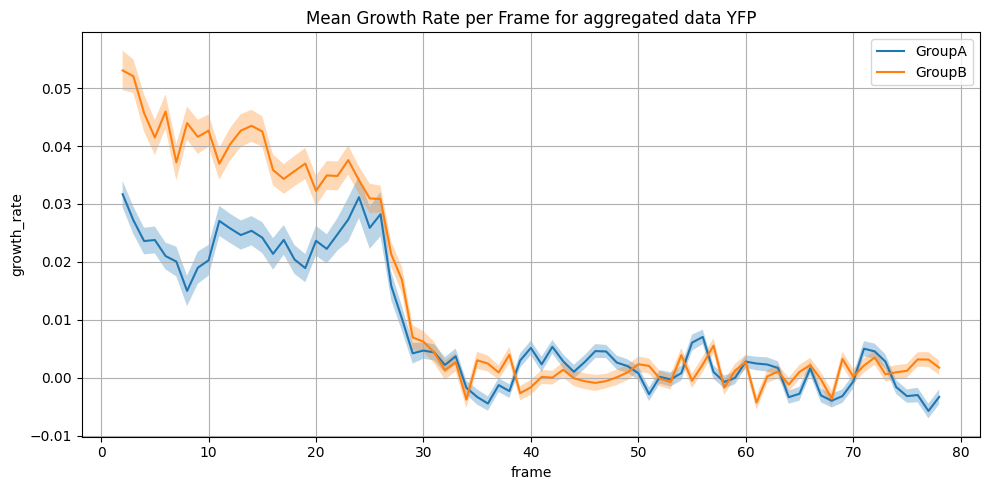

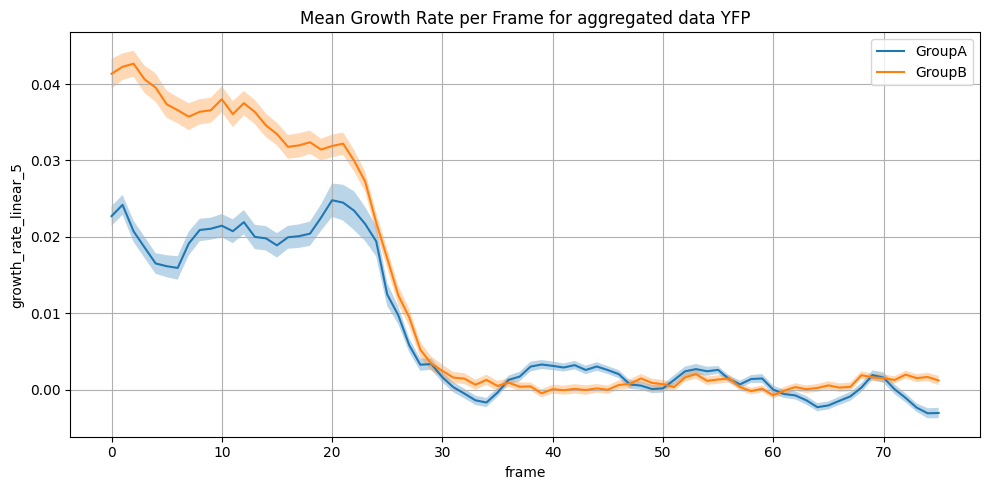

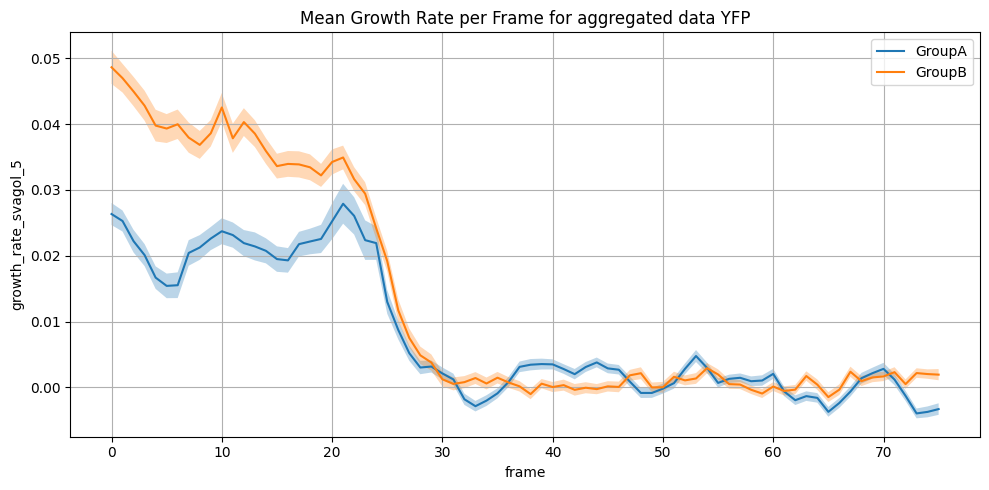

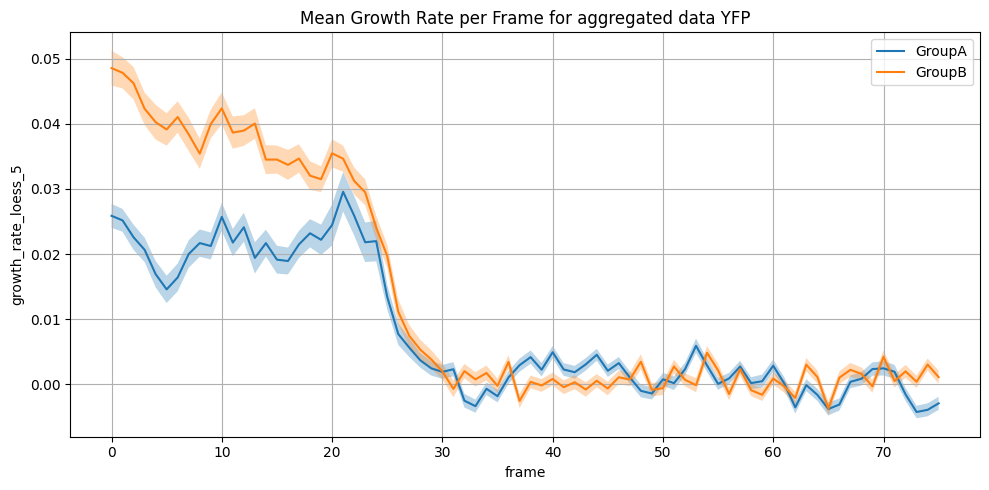

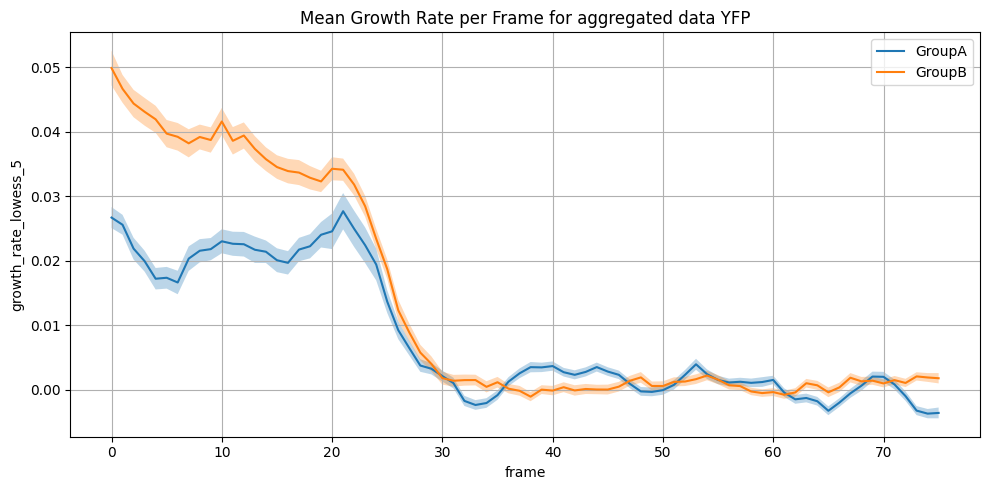

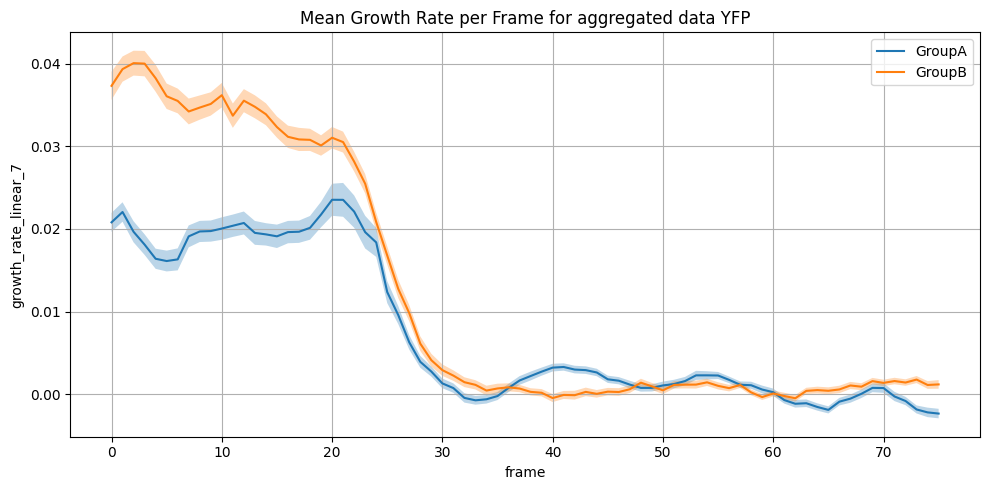

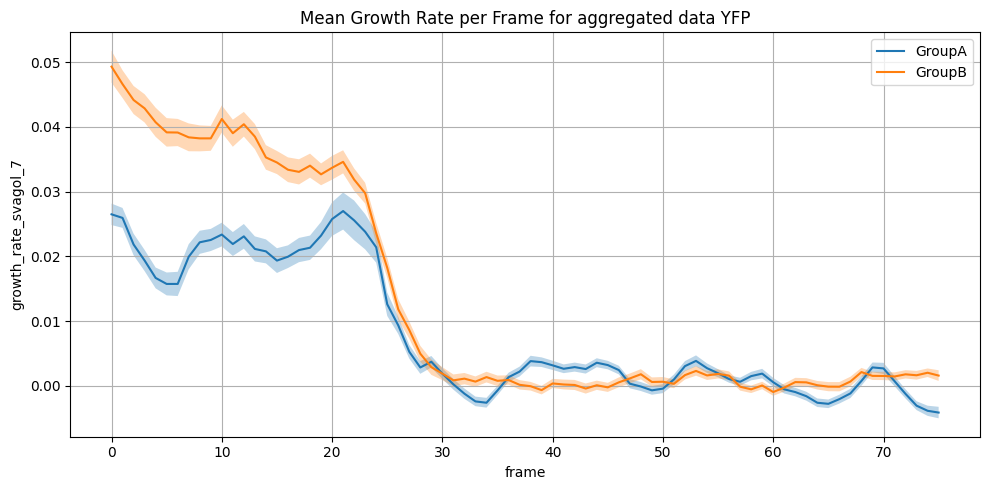

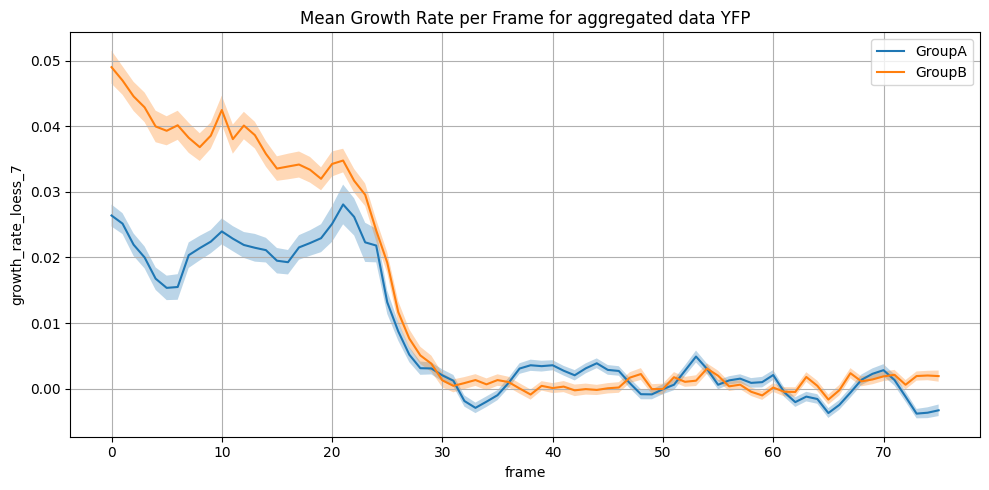

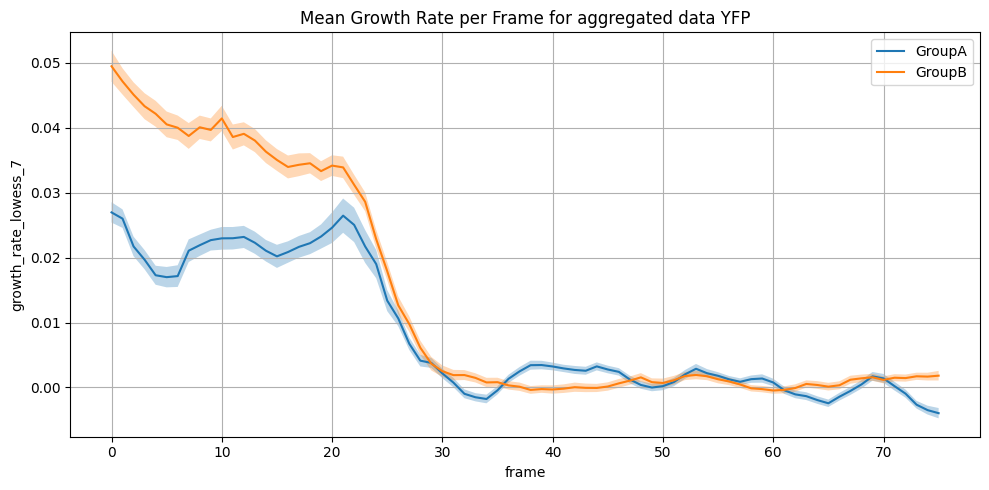

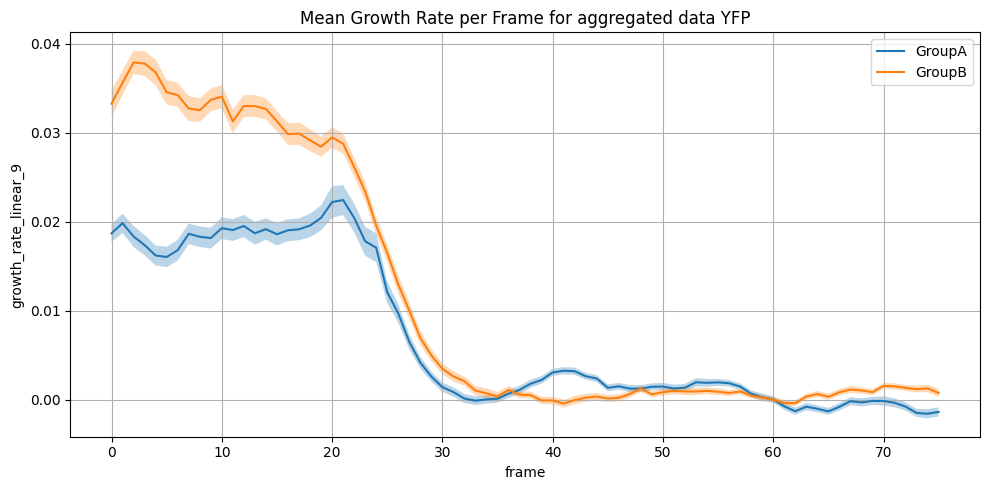

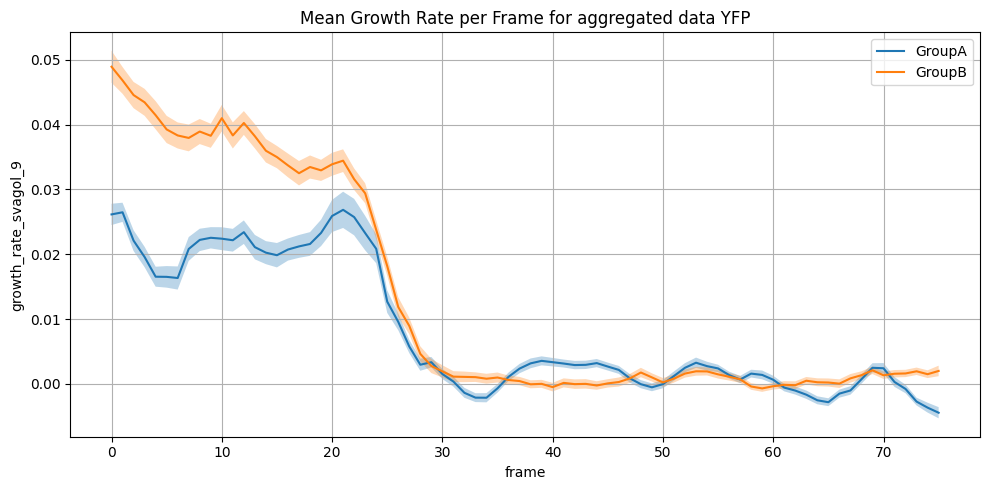

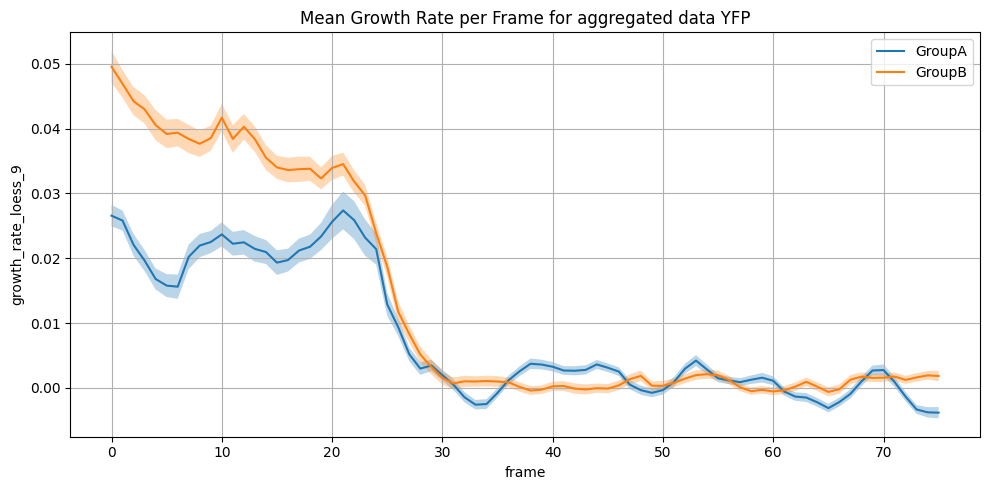

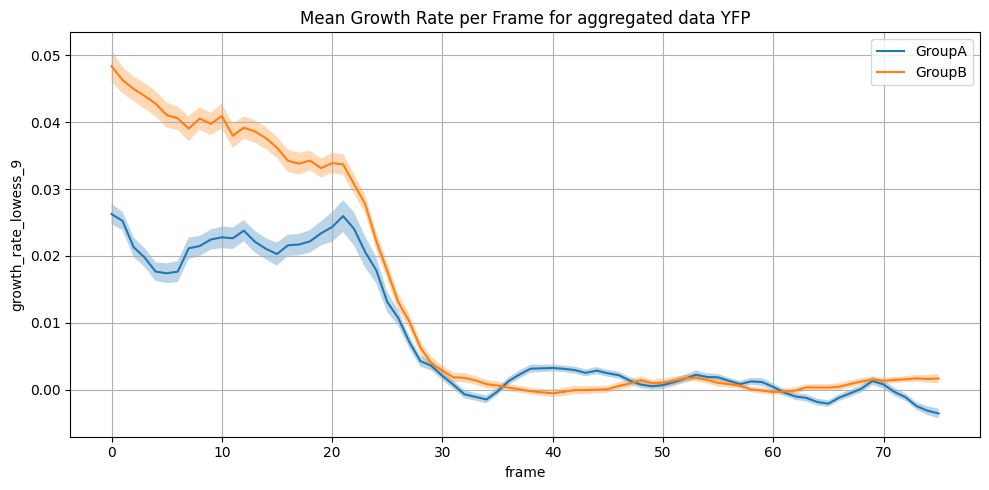

In [7]:
#Note, only works if you have loaded metadata template with groups

COLOR_CHANNELS = ["YFP"]
METADATA_GROUP_VARIABLE = "group"

exp.plot_rates(rate_column="growth_rate",group_by = METADATA_GROUP_VARIABLE, color_channels = COLOR_CHANNELS, flip_grouping=True)

for w in SMOOTHING_WINDOWS:
    for m in METHODS:
        growth_rate_column = "growth_rate" + m["postfix"] + f"_{w}"
        exp.plot_rates(rate_column=growth_rate_column,group_by = METADATA_GROUP_VARIABLE, color_channels = COLOR_CHANNELS, flip_grouping=True)
